In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
MEMBER, STUDENT_ID, MODEL_NAME = 'Ukwaththa U.K.A.A.N.', 'IT25101545', 'Logistic Regression'
print(f'{MEMBER} ({STUDENT_ID}) - {MODEL_NAME}')

Ukwaththa U.K.A.A.N. (IT25101545) - Logistic Regression


In [2]:
# data loading and preprocessing
# load data
DATA = 'fitness_dataset.csv'
if not os.path.exists(DATA):
    try:
        from google.colab import files
        up = files.upload(); DATA = list(up.keys())[0]
    except ImportError:
        raise FileNotFoundError('Put fitness_dataset.csv next to this notebook.')
df = pd.read_csv(DATA)
print('Shape:', df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])
print(df['smokes'].value_counts().to_dict())
df.head()

Saving fitness_dataset.csv to fitness_dataset.csv
Shape: (2000, 11)
sleep_hours    160
dtype: int64
{'yes': 711, '0': 581, 'no': 518, '1': 190}


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


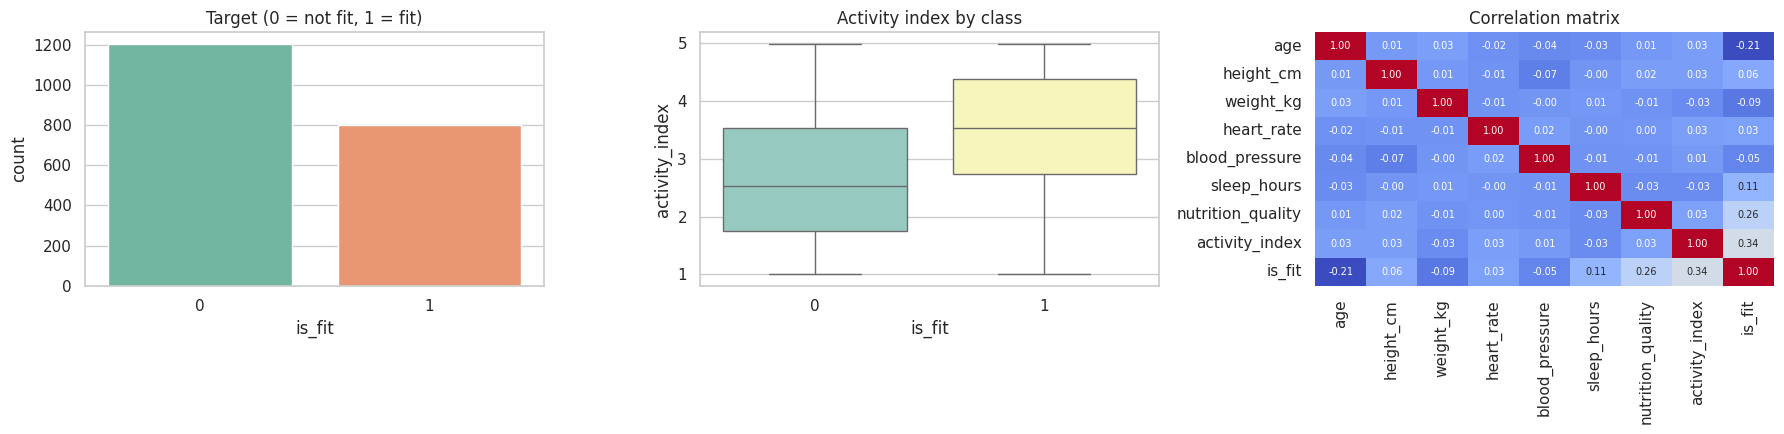

In [3]:
# eda
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
sns.countplot(data=df, x='is_fit', palette='Set2', ax=ax[0]); ax[0].set_title('Target (0 = not fit, 1 = fit)')
sns.boxplot(data=df, x='is_fit', y='activity_index', palette='Set3', ax=ax[1]); ax[1].set_title('Activity index by class')
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False, ax=ax[2], annot_kws={'size': 7}); ax[2].set_title('Correlation matrix')
plt.tight_layout(); plt.show()

In [4]:
# cleaning, features, split
d = df.copy()
d['smokes'] = d['smokes'].astype(str).str.lower().map({'yes': 1, '1': 1, 'no': 0, '0': 0})
d['gender'] = (d['gender'] == 'M').astype(int)
d['bmi'] = d['weight_kg'] / (d['height_cm'] / 100) ** 2

y = d['is_fit']
BASE_COLS = ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours',
             'nutrition_quality', 'activity_index', 'smokes', 'gender']
X = d[BASE_COLS + ['bmi']]
print(y.value_counts(normalize=True).round(3).to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

{0: 0.6, 1: 0.4}
Train: (1600, 11) | Test: (400, 11)


In [5]:
# preprocessing variants
VARIANTS = {
 'V1 Median impute, no scaling'  : dict(cols=BASE_COLS,                                        scaler=None,       pca=False),
 'V2 Median + StandardScaler'    : dict(cols=BASE_COLS,                                        scaler='standard', pca=False),
 'V3 Median + RobustScaler'      : dict(cols=BASE_COLS,                                        scaler='robust',   pca=False),
 'V4 Standard + BMI feature'     : dict(cols=BASE_COLS + ['bmi'],                              scaler='standard', pca=False),
 'V5 Standard, gender removed'   : dict(cols=[c for c in BASE_COLS if c != 'gender'],          scaler='standard', pca=False),
 'V6 Standard + PCA (95% var)'  : dict(cols=BASE_COLS,                                        scaler='standard', pca=True),
}

def make_pipeline(v, clf):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if v['scaler'] == 'standard': steps.append(('scaler', StandardScaler()))
    if v['scaler'] == 'robust':   steps.append(('scaler', RobustScaler()))
    if v['pca']:                  steps.append(('pca', PCA(n_components=0.95, random_state=42)))
    steps.append(('clf', clf))
    return Pipeline(steps)

def get_scores(model, X_):
    return model.predict_proba(X_)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_)

def evaluate(model, X_, y_):
    p = model.predict(X_)
    return dict(Accuracy=accuracy_score(y_, p), Precision=precision_score(y_, p), Recall=recall_score(y_, p),
                F1=f1_score(y_, p), ROC_AUC=roc_auc_score(y_, get_scores(model, X_)))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
BASE = LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)
print('Base estimator:', BASE)

Base estimator: LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')


,#Features,CV F1 (mean),CV F1 (std),Test Acc,Test F1,Test AUC,Time (s)
Variant,,,,,,,
"V1 Median impute, no scaling",10,0.7368,0.0201,0.7725,0.6936,0.8472,0.1593
V2 Median + StandardScaler,10,0.7310,0.0260,0.7725,0.6936,0.8458,0.1091
V3 Median + RobustScaler,10,0.7328,0.0245,0.7725,0.6936,0.8456,0.1161
V4 Standard + BMI feature,11,0.7384,0.0211,0.7875,0.7138,0.8488,0.1041
"V5 Standard, gender removed",9,0.7080,0.0126,0.7600,0.6735,0.8222,0.0924
V6 Standard + PCA (95% var),10,0.7310,0.0260,0.7725,0.6936,0.8458,0.1236


Best preprocessing by 5-fold CV F1: V4 Standard + BMI feature


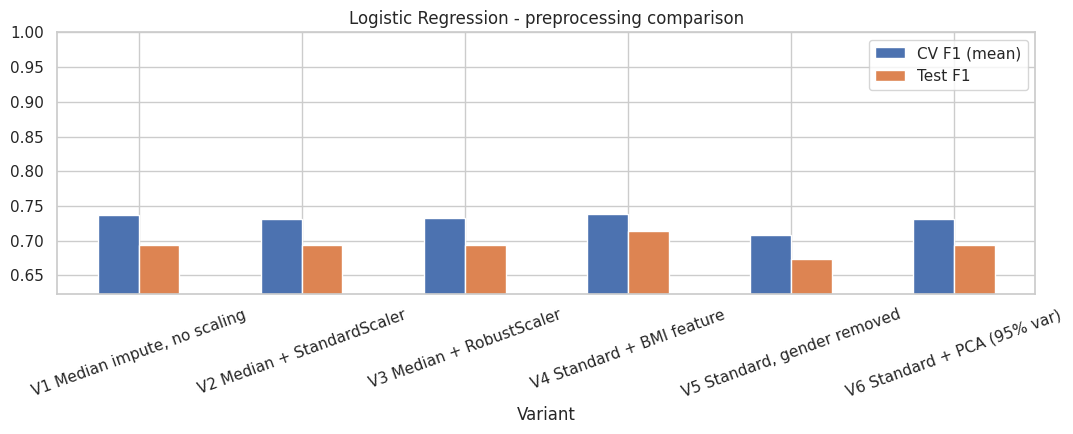

In [6]:
# preprocessing comparison, 5-fold cv
rows, n_fits = [], 0
for name, v in VARIANTS.items():
    t0 = time.time()
    pipe = make_pipeline(v, clone(BASE))
    cv_f1 = cross_val_score(pipe, X_train[v['cols']], y_train, cv=cv, scoring='f1'); n_fits += cv.get_n_splits()
    pipe.fit(X_train[v['cols']], y_train); n_fits += 1
    m = evaluate(pipe, X_test[v['cols']], y_test)
    rows.append({'Variant': name, '#Features': len(v['cols']), 'CV F1 (mean)': cv_f1.mean(), 'CV F1 (std)': cv_f1.std(),
                 'Test Acc': m['Accuracy'], 'Test F1': m['F1'], 'Test AUC': m['ROC_AUC'], 'Time (s)': time.time() - t0})
res_A = pd.DataFrame(rows).set_index('Variant')
display(res_A.round(4))
best_variant = res_A['CV F1 (mean)'].idxmax(); best_v = VARIANTS[best_variant]
print(f'Best preprocessing by 5-fold CV F1: {best_variant}')

ax = res_A[['CV F1 (mean)', 'Test F1']].plot.bar(figsize=(11, 4.5), rot=20, color=['#4c72b0', '#dd8452'])
ax.set_ylim(max(0, res_A[['CV F1 (mean)', 'Test F1']].min().min() - 0.05), 1); ax.set_title(f'{MODEL_NAME} - preprocessing comparison')
plt.tight_layout(); plt.show()

In [7]:
# Hyperparameter tuning
# grid search
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
}
gs = GridSearchCV(make_pipeline(best_v, clone(BASE)), param_grid, cv=cv, scoring='f1', n_jobs=-1, refit=True, return_train_score=True)
t0 = time.time(); gs.fit(X_train[best_v['cols']], y_train)
n_combos = len(gs.cv_results_['params']); n_fits += n_combos * cv.get_n_splits() + 1
print(f'{n_combos} combinations x {cv.get_n_splits()} folds, {time.time()-t0:.0f}s')
print('Best params:', gs.best_params_); print(f'Best 5-fold CV F1: {gs.best_score_:.4f}')

cvr = pd.DataFrame(gs.cv_results_)
cols = [c for c in cvr.columns if c.startswith('param_')] + ['mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
top = cvr[cols].sort_values('rank_test_score').head(8).rename(columns=lambda c: c.replace('param_clf__', ''))
top['overfit_gap'] = top['mean_train_score'] - top['mean_test_score']
display(top.round(4).reset_index(drop=True))

10 combinations x 5 folds, 5s
Best params: {'clf__C': 1, 'clf__penalty': 'l1'}
Best 5-fold CV F1: 0.7407


,C,penalty,mean_train_score,mean_test_score,std_test_score,rank_test_score,overfit_gap
0,1.00,l1,0.7428,0.7407,0.0199,1,0.0021
1,0.10,l2,0.7414,0.7397,0.0222,2,0.0016
2,1.00,l2,0.7411,0.7384,0.0211,3,0.0027
3,100.00,l1,0.7406,0.7361,0.0140,4,0.0045
4,100.00,l2,0.7405,0.7361,0.0140,4,0.0043
5,0.10,l1,0.7382,0.7358,0.0168,6,0.0024
6,0.01,l2,0.7401,0.7352,0.0213,7,0.0050
7,10.00,l1,0.7406,0.7346,0.0166,8,0.0061


Logistic Regression | V4 Standard + BMI feature | {'clf__C': 1, 'clf__penalty': 'l1'}
  Accuracy: 0.7850
 Precision: 0.7721
    Recall: 0.6562
        F1: 0.7095
   ROC_AUC: 0.8488

              precision    recall  f1-score   support

     Not fit       0.79      0.87      0.83       240
         Fit       0.77      0.66      0.71       160

    accuracy                           0.79       400
   macro avg       0.78      0.76      0.77       400
weighted avg       0.78      0.79      0.78       400



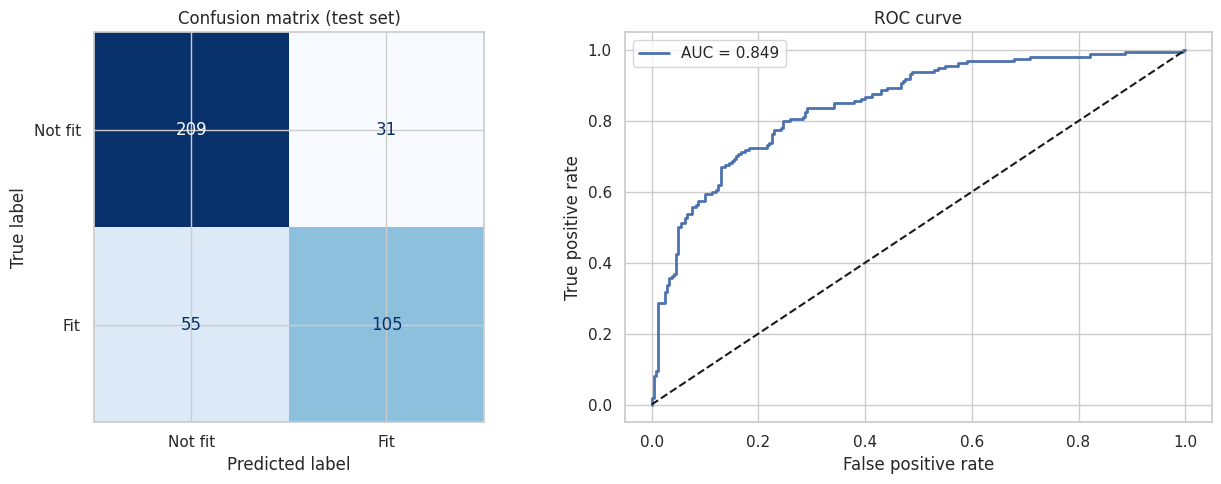

Train accuracy 0.8013 vs test accuracy 0.7850 (gap 0.0162)


In [8]:
# test set evaluation
# test set results
final_model = gs.best_estimator_
Xte = X_test[best_v['cols']]
final = evaluate(final_model, Xte, y_test)
print(f'{MODEL_NAME} | {best_variant} | {gs.best_params_}')
for k, v_ in final.items(): print(f'{k:>10}: {v_:.4f}')
print(); print(classification_report(y_test, final_model.predict(Xte), target_names=['Not fit', 'Fit']))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(final_model, Xte, y_test, display_labels=['Not fit', 'Fit'], cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title('Confusion matrix (test set)')
fpr, tpr, _ = roc_curve(y_test, get_scores(final_model, Xte))
ax[1].plot(fpr, tpr, lw=2, label=f"AUC = {final['ROC_AUC']:.3f}"); ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate'); ax[1].set_title('ROC curve'); ax[1].legend()
plt.tight_layout(); plt.show()

tr = evaluate(final_model, X_train[best_v['cols']], y_train)
print(f"Train accuracy {tr['Accuracy']:.4f} vs test accuracy {final['Accuracy']:.4f} (gap {tr['Accuracy']-final['Accuracy']:.4f})")

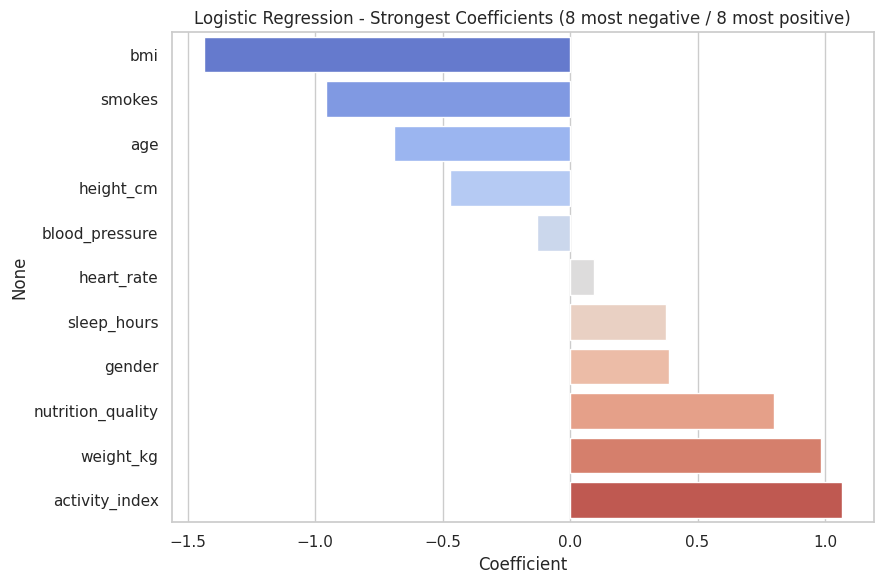

In [9]:
clf = final_model.named_steps['clf']
if best_v['pca']:
    print('PCA variant selected - coefficients refer to principal components, skipping.')
else:
    coef = pd.Series(clf.coef_[0], index=best_v['cols']).sort_values()
    top = pd.concat([coef.head(8), coef.tail(8)])
    plt.figure(figsize=(9,6)); sns.barplot(x=top.values, y=top.index, palette='coolwarm')
    plt.title('Logistic Regression - Strongest Coefficients (8 most negative / 8 most positive)')
    plt.xlabel('Coefficient'); plt.tight_layout(); plt.show()

In [10]:
# stability check, 10 different random 80/20 splits
accs, f1s = [], []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(X[best_v['cols']], y, test_size=0.20, random_state=seed, stratify=y)
    m_ = clone(final_model).fit(Xa, ya); n_fits += 1
    r_ = evaluate(m_, Xb, yb); accs.append(r_['Accuracy']); f1s.append(r_['F1'])
rep = dict(acc_mean=float(np.mean(accs)), acc_std=float(np.std(accs)), f1_mean=float(np.mean(f1s)), f1_std=float(np.std(f1s)),
           acc_min=float(np.min(accs)), acc_max=float(np.max(accs)))
print(f"Accuracy over 10 splits: {rep['acc_mean']:.4f} +/- {rep['acc_std']:.4f} (min {rep['acc_min']:.4f}, max {rep['acc_max']:.4f})")
print(f"F1 over 10 splits:       {rep['f1_mean']:.4f} +/- {rep['f1_std']:.4f}")

Accuracy over 10 splits: 0.7958 +/- 0.0165 (min 0.7675, max 0.8200)
F1 over 10 splits:       0.7334 +/- 0.0230


In [11]:
# summary and save results
total_configs = len(VARIANTS) + n_combos
print(f'Model: {MODEL_NAME}')
print(f'Configurations evaluated: {total_configs} ({len(VARIANTS)} preprocessing + {n_combos} hyperparameter combinations)')
print(f'Total fits incl. cross-validation: {n_fits}')
print(f'Best preprocessing: {best_variant}')
print(f'Best hyperparameters: {gs.best_params_}')
print(f"Test: Accuracy={final['Accuracy']:.4f} Precision={final['Precision']:.4f} Recall={final['Recall']:.4f} F1={final['F1']:.4f} AUC={final['ROC_AUC']:.4f}")

print('\n--- Conclusion ---')
print(f"Best preprocessing '{best_variant}' (CV F1 {res_A['CV F1 (mean)'].max():.4f}); worst '{res_A['CV F1 (mean)'].idxmin()}' ({res_A['CV F1 (mean)'].min():.4f}).")
print(f"Tuning moved test F1 from {res_A.loc[best_variant, 'Test F1']:.4f} to {final['F1']:.4f}.")
print(f"Train-test accuracy gap {tr['Accuracy']-final['Accuracy']:.4f}; accuracy over 10 splits {rep['acc_mean']:.4f} +/- {rep['acc_std']:.4f}.")

out = dict(member=MEMBER, student_id=STUDENT_ID, model=MODEL_NAME, best_variant=best_variant,
           best_params={k.replace('clf__', ''): (list(v_) if isinstance(v_, tuple) else v_) for k, v_ in gs.best_params_.items()},
           cv_f1=float(gs.best_score_), test={k: float(v_) for k, v_ in final.items()}, repeated=rep,
           train_acc=float(tr['Accuracy']), n_configs=int(total_configs), n_fits=int(n_fits),
           preprocessing_f1={k: float(v_) for k, v_ in res_A['CV F1 (mean)'].items()},
           preprocessing_test_acc={k: float(v_) for k, v_ in res_A['Test Acc'].items()})
with open(f'results_{STUDENT_ID}.json', 'w') as f: json.dump(out, f, indent=2, default=str)
print(f'Saved results_{STUDENT_ID}.json')

Model: Logistic Regression
Configurations evaluated: 16 (6 preprocessing + 10 hyperparameter combinations)
Total fits incl. cross-validation: 97
Best preprocessing: V4 Standard + BMI feature
Best hyperparameters: {'clf__C': 1, 'clf__penalty': 'l1'}
Test: Accuracy=0.7850 Precision=0.7721 Recall=0.6562 F1=0.7095 AUC=0.8488

--- Conclusion ---
Best preprocessing 'V4 Standard + BMI feature' (CV F1 0.7384); worst 'V5 Standard, gender removed' (0.7080).
Tuning moved test F1 from 0.7138 to 0.7095.
Train-test accuracy gap 0.0162; accuracy over 10 splits 0.7958 +/- 0.0165.
Saved results_IT25101545.json
